In [ ]:
###Lab 10

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

In [4]:
#Creamos el grafo
grafo=nx.DiGraph()

In [5]:
grafo.add_weighted_edges_from([
    ("Oeste", "Airport", 18),
    ("Este", "Airport", 20),
    ("Norte", "Este", 8),
    ("Norte", "Sur", 30),
    ("Centro", "Sur", 15),
    ("Centro", "Norte", 10),
    ("Centro", "Este", 25),
    ("Sur", "Oeste", 9),
    ("Norte", "Oeste", 15)
])

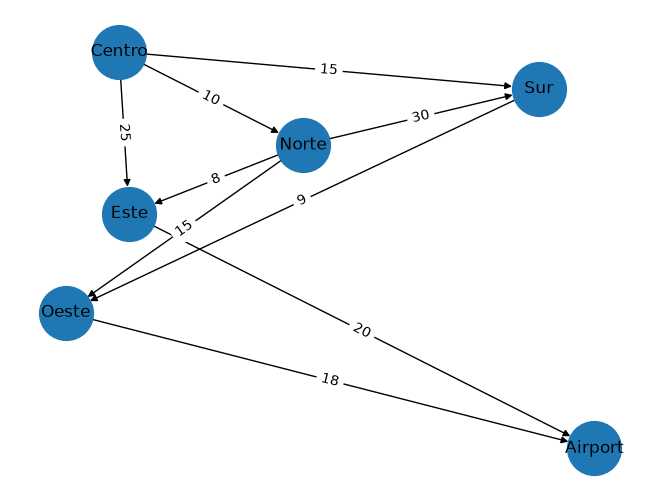

In [7]:
#Imprimimos el grafo
pos=nx.spring_layout(grafo, seed=12)
nx.draw(
    grafo,
    pos,
    with_labels=True,
    node_size=1500,
    arrows=True
)
labels=nx.get_edge_attributes(grafo,"weight")
nx.draw_networkx_edge_labels(
    grafo,
    pos,
    edge_labels=labels
)
plt.show()

In [8]:
#Mostramos las rutas
rutas=list(
    nx.all_simple_paths(
        grafo,
        source="Centro",
        target="Airport"
    )
)

In [9]:
#Imprimimos las rutas
for i, ruta in enumerate(rutas, start=1):
    print(f"Ruta{i}:{ruta}")

Ruta1:['Centro', 'Sur', 'Oeste', 'Airport']
Ruta2:['Centro', 'Norte', 'Este', 'Airport']
Ruta3:['Centro', 'Norte', 'Sur', 'Oeste', 'Airport']
Ruta4:['Centro', 'Norte', 'Oeste', 'Airport']
Ruta5:['Centro', 'Este', 'Airport']


In [10]:
### Calculamos el costo
def costo_ruta (grafo, ruta):
    costo=0
    for i in range (len(ruta)-1):
        costo += grafo [ruta[i]][ruta[i+1]]["weight"]
    return costo

In [11]:
#Imprimimos el costo
for i, ruta in enumerate(rutas, start=1):
    costo=costo_ruta(grafo,ruta)
    print(f"Ruta{i}:{ruta}->{costo}unidades")

Ruta1:['Centro', 'Sur', 'Oeste', 'Airport']->42unidades
Ruta2:['Centro', 'Norte', 'Este', 'Airport']->38unidades
Ruta3:['Centro', 'Norte', 'Sur', 'Oeste', 'Airport']->67unidades
Ruta4:['Centro', 'Norte', 'Oeste', 'Airport']->43unidades
Ruta5:['Centro', 'Este', 'Airport']->45unidades


In [12]:
#Elegir la ruta más corta
costos=[costo_ruta(grafo,ruta)
        for ruta in rutas
       ]
mejor_ruta=costos.index(min(costos))

In [13]:
#Imprimir la mejor ruta
print(f"La mejor ruta es:{mejor_ruta+1}")
print(f"El camino corto es: {costos[mejor_ruta]}")

La mejor ruta es:2
El camino corto es: 38


In [14]:
#Algoritmo Dijkstra para obtener la ruta más corta
ruta_mas_corta=nx.dijkstra_path(grafo,source= "Centro", target= "Airport", weight= "weight")
tiempo_total=nx.dijkstra_path_length(grafo, source="Centro", target= "Airport", weight= "weight")

In [16]:
#Imprimir
print(f"La ruta más corta es: {ruta_mas_corta}")
print(f"El tiempo total es: {tiempo_total} minutos")

La ruta más corta es: ['Centro', 'Norte', 'Este', 'Airport']
El tiempo total es: 38 minutos
